In [1]:
!pip install pycountry

In [2]:
# importing of all libraries
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import missingno as msno
import pycountry
import plotly.express as px
import geopandas as gpd
import os

pd.set_option('display.max_columns', None)

# Check if we're running in Colab
try:
    from google.colab import drive
    # If this succeeds, we're in Colab
    is_colab = True
    drive.mount('/content/drive')
    # Replace 'MyDataFolder' with the actual path to your data folder in Google Drive
    drive_data_path = '/content/drive/MyDrive/EDUCATION/data'
except ModuleNotFoundError:
    # We're not in Colab
    is_colab = False
    # Set the local path as specified
    drive_data_path = r'C:\Users\shahu\EDUCATION\data'  # Using raw string for Windows path

# Check if the directory exists before changing the directory
if os.path.exists(drive_data_path):
    os.chdir(drive_data_path)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Error: The directory '{drive_data_path}' was not found.")
    print("Please check the path and make sure it exists.")

Changed working directory to: C:\Users\shahu\EDUCATION\data


# Project Context

We are working with an EdTech startup called academy, which provides online learning content aimed at high school and university students.

Mark, the manager, has called a meeting to discuss the company’s international expansion strategy. As part of this process, he has requested an exploratory data analysis (EDA) to support decision-making.

## Mission Objectives



*   Investigate whether World Bank education datasets can provide valuable insights for guiding expansion decisions.
*   Identify countries with strong potential demand for academy’s online learning services.
*   Explore how this potential may evolve over time, using available education and demographic indicators.



## Expected Outcome

By the end of this analysis, we aim to determine whether these datasets can effectively guide academy in selecting target countries for its international expansion.

# Processed Data


1.   Indicator_data
2.   Country_indicator



# Indicator_data


""
### Description

The `EdStatsSeries` table contains data about indicators, with the following variables:
- `Series Code`: Unique identifier for each indicator series.
- `Topic`: Category or theme of the indicator (to be dropped).
- `Indicator Name`: Name/description of the indicator.

### Assessment

For further analysis, only `Series Code` and `Indicator Name` are relevant.
The `Topic` variable will be dropped as other variables.
"""


In [3]:
indicator_data = pd.read_csv('EdStatsSeries.csv')
indicator_data.head()


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
indicator_data.shape

(3665, 21)

In [5]:
print(indicator_data.duplicated().sum())

0


In [6]:
indicator_data.drop_duplicates().reset_index()

,index,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3661,3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3662,3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663,3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,NaN,Secondary,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
indicator_data.dtypes

Series Code                             object
Topic                                   object
Indicator Name                          object
Short definition                        object
Long definition                         object
Unit of measure                        float64
Periodicity                             object
Base Period                             object
Other notes                             object
Aggregation method                      object
Limitations and exceptions              object
Notes from original source             float64
General comments                        object
Source                                  object
Statistical concept and methodology     object
Development relevance                   object
Related source links                    object
Other web links                        float64
Related indicators                     float64
License Type                           float64
Unnamed: 20                            float64
dtype: object

In [8]:
missing_data = indicator_data.isna().mean().sort_values(ascending=False)
print(missing_data)

Unnamed: 20                            1.000000
Notes from original source             1.000000
License Type                           1.000000
Related indicators                     1.000000
Other web links                        1.000000
Unit of measure                        1.000000
Development relevance                  0.999181
General comments                       0.996180
Limitations and exceptions             0.996180
Statistical concept and methodology    0.993724
Aggregation method                     0.987176
Periodicity                            0.972988
Related source links                   0.941337
Base Period                            0.914325
Other notes                            0.849386
Short definition                       0.411733
Topic                                  0.000000
Source                                 0.000000
Long definition                        0.000000
Indicator Name                         0.000000
Series Code                            0

In [9]:
indicator_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

In [10]:
indicator_data.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# deleting columns with missing values and unnecessary columns through judgement

columns_tokeep = ['Series Code','Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

,Series Code,Indicator Name
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...


### Processing

In this step, **only the chosen indicators of interest** will be selected from the `indicators_values` dataframe. This filtering ensures that the analysis focuses exclusively on the **relevant indicators**, excluding any unnecessary or unrelated data.This is performed by manually reviewing the excel files with the topics and indicators and selecting indicators of interest in function of topics and indicator names.

In [12]:
# Read the Excel file
indicator_list = pd.read_excel("Indicators.xlsx")

# Make sure to extract the list of Series Codes
codes_to_keep = indicator_list["Series Code"].unique().tolist()

# Filter indicator_data based on the codes
indicator_data = indicator_data[indicator_data["Series Code"].isin(codes_to_keep)]

print(indicator_data)

                Series Code                                     Indicator Name
610          IT.CMP.PCMP.P2                Personal computers (per 100 people)
611          IT.NET.USER.P2                    Internet users (per 100 people)
1658         NY.GDP.MKTP.CD                                  GDP (current US$)
1659         NY.GDP.MKTP.KD                            GDP (constant 2010 US$)
1662         NY.GDP.PCAP.CD                       GDP per capita (current US$)
1930      PRJ.POP.1519.3.MF  Projection: Population age 15-19 in thousands ...
1933      PRJ.POP.1519.4.MF  Projection: Population age 15-19 in thousands ...
2298         SE.SEC.ENRL.GC  Enrolment in secondary general, both sexes (nu...
2307            SE.SEC.ENRR   Gross enrolment ratio, secondary, both sexes (%)
2332            SE.TER.ENRL  Enrolment in tertiary education, all programme...
2376      SE.XPD.SECO.PC.ZS  Government expenditure per secondary student a...
2378      SE.XPD.TERT.PC.ZS  Government expenditure 

# Country_indicator

""
### Description
This table contains records of indicator implementations by country, with the following columns:
- **`country_code`**: Unique identifier for each country.
- **`series_code`**: Unique identifier for each indicator (matches the `series_code` in the `Indicator Data` table).
- **`year`**: Year the indicator was implemented in the country.
- **`description`**: Likely a note or context about the implementation providing the reliability of the source (e.g., details or conditions).


### Assessment



- The table appears to track **which indicators (`series_code`) have been implemented in each country (`country_code`) and the corresponding year**.
- At this stage, this table does not seem immediately useful for the current analysis, as the focus is on indicator metadata rather than country-specific implementation timelines.
""



In [13]:
country_indicator= pd.read_csv('EdStatsFootNote.csv')
country_indicator.head()


,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


In [14]:
country_indicator.shape

(643638, 5)

In [15]:
missing_values = country_indicator.isna().mean().sort_values(ascending=False)
print(missing_values)

Unnamed: 4     1.0
CountryCode    0.0
SeriesCode     0.0
Year           0.0
DESCRIPTION    0.0
dtype: float64


In [16]:
country_indicator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB


In [17]:
country_indicator.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


# Indicator_values

"""

### Description
This table provides **time-series data** for indicators by country, including:
- **`country`**: Name or code of the country.
- **`indicator_name`**: Name of the indicator.
- **`indicator_code`**: Unique identifier for the indicator.
- **`year`**: Year of observation (1970–2100).
- **`value`**: Recorded value of the indicator for the given country and year.

### Assessment
- This is the **core table** for the project, as it contains the actual indicator values over time.
- Further analysis will focus on **data completeness** and identifying any gaps (e.g., missing values for specific countries or years).
"""




In [18]:
indicator_values = pd.read_csv('EdStatsData.csv')
indicator_values.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,60.999962,61.92268,62.69342,64.383186,65.617767,66.085152,66.608139,67.290451,68.510094,69.033211,69.944908,71.04187,71.693779,71.699097,71.995819,72.602837,70.032722,70.464821,72.645683,71.81176,73.903511,74.425201,75.110817,76.254318,77.245682,78.800522,80.051399,80.805389,81.607063,82.489487,82.685509,83.280342,84.011871,84.195961,85.211998,85.24514,86.101669,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
indicator_values.shape


(886930, 70)

In [ ]:
indicator_values.describe()

In [ ]:
indicator_values.info()

In [ ]:
missing_values=indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

### Processing 1

In first step, we will:
- **keep relevant countries**: Retain only countries that are relevant and remove eveything else
- **Filter year columns**: Retain only the columns corresponding to **relevant years** for the analysis.
  - Remove columns with **very old years** (outside the scope of the analysis before 2006).
  - Remove columns with **future years** (e.g., beyond 2025).
- **Analyze missing values**: Use the `missingno` module to visualize the distribution of missing values across the dataset.
- **Handle missing years**: Add missing years and years from 2006 to 2025 as this is relevant for analysis.



In [ ]:
# Get all valid alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]

# Filter for invalid countries
invalid_countries = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]

# Select both 'Country Code' and 'Country Name' columns, and drop duplicates
unique_invalid_countries = invalid_countries[['Country Code', 'Country Name']].drop_duplicates()

# Print the result of invalid countries
print(unique_invalid_countries)



In [ ]:
# filtering on valid countries only. hence, eliminating other geographic levels like regions.
indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.reset_index()
indicator_values.shape

In [ ]:
# show all the missing values throughout years

# Identify actual year columns in the DataFrame
all_cols = indicator_values.columns.tolist()
year_cols = [col for col in all_cols if col.isdigit()]

# Split year columns into two groups
half = len(year_cols) // 2
years_group1 = year_cols[:half]
years_group2 = year_cols[half:]


# Plot missingno matrix for the first group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group1])
plt.title('Missing Values - Years 1970 to ' + years_group1[-1])
plt.show()

# Plot missingno matrix for the second group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group2])
plt.title('Missing Values - Years ' + years_group2[0] + ' to 2100')
plt.show()

### Processing 2

All the data before 2010 is discarded as considered to be old. The indicator data is well populated from 2010 to 2015.

 as we find oursekves in the year 2025, hence deleting the data from 2025 to beyind as there are projections and the data was last uploaded in Oct 2024.

in addition, we also drop 2020 as the same celles seem to be filled as the following years which may be related to estimations. Hence, we keep the range from 2010 to 2016.

then add columns from 2017 to 2025.


In [ ]:
# Drop columns for years 1970 to 2007 and 2025 to 2100
years_to_drop = [str(year) for year in range(1970, 2008)] + [str(year) for year in range(2025, 2101)]
indicator_values = indicator_values.drop(columns=years_to_drop, errors='ignore')

# Drop columns that start with "Unnamed"
unnamed_cols = [col for col in indicator_values.columns if col.startswith('Unnamed')]
indicator_values = indicator_values.drop(columns=unnamed_cols, errors='ignore')

# Add columns for years 2017 to 2025 with NaN values
years_to_add = [str(year) for year in range(2017, 2025)]
for year in years_to_add:
    if year not in indicator_values.columns:
        indicator_values[year] = np.nan


# Display the first few rows and columns to verify the changes
display(indicator_values.columns.tolist())

In [ ]:
msno.heatmap(indicator_values)

# seriescode_description

"""


### Description
This table contains:
- **`country`**: Name or code of the country.
- **`series_code`**: Unique identifier for the indicator series.
- **`description`**: Likely a note about whether or how the series code applies to the country and the source of data.

### Assessment

- This table is **irrelevant** for the current analysis, as it does not provide actionable or necessary information for the project's objectives.
- No further exploration of this file is required.
"""



In [ ]:
seriescode_description = pd.read_csv('EdStatsCountrySeries.csv')
seriescode_description.head()

In [ ]:
seriescode_description.shape

# Country_characteristics


"""


### Description
This table contains **country-level metadata**, including:
- **`country`**: Name or code of the country.
- **`currency`**: Official currency of the country.
- **`income_group`**: Classification of the country by income level (e.g., low-income, high-income).
- **`lending_category`**: Classification related to lending eligibility or terms.
- **`system_of_accounts`**: Accounting standards or systems used.
- **`survey_dates`**: Dates and explanations of surveys conducted (e.g., PPP surveys).

The table provides **characteristics of countries**, such as economic classifications and survey timelines.

### Assessment
- While the **`income_group`** variable is relevant.
- The `indicators_values` dataframe already includes all necessary indicator data, including PPP and technology-related metrics (e.g., internet and computer penetration).
- As a result, this table is not considered in further analysis.
"""
```

In [ ]:
country_characteristics = pd.read_csv('EdStatsCountry.csv')
country_characteristics.head()

# ANALYSIS OF CONSOLIDATED DATA




### Processing 1: Merge and choose indicators
- Combine data from all retained tables.
- **Merge keys**: Use **`Indicator Code`** and **`Country Code`** as the primary keys for merging.
- The data is merged such that the resultant table has:

**Indicator_values contains only the list if 19 indicators chosen among the indicator_data based on professional judgement.**

In [ ]:
#Merge the dataframes to acheive a consilidated table



consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Series Code', # Adjust this to match the actual column name in indicator_data
    how="inner"
)

consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

print(consolidated_table.shape)


consolidated_table = consolidated_table[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']]
consolidated_table.head()


### Processing 2 : fill rate evaluation and further selection of indicators
- Evaluate the **fill rates** for each selected indicator and for each year.
- Calculate the **average fill rate** across all years for each indicator.
- Drop all the indicators with **low fill rates**.

Post-Filtering
- Retain a **further restrained list of indicators** based on the fill rate analysis and professional judgement.
- Apply this filtered list to the **consolidated table** for further processing.

In [ ]:
columns_to_check = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')

# Fixed line: removed the 'name' parameter which is not valid for DataFrame.reset_index()
fill_rate_per_group.reset_index().to_csv('fill_rate_per_group.csv', index=False)


# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)

In [ ]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

# Filter the DataFrame
consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
consolidated_table.shape

In [ ]:
consolidated_table.head()

### Processing 3 : Correlation Analysis of indicators

**Melt the consolidated table**: Reshape the data to prepare for correlation analysis.
- **Compute Pearson correlation matrix**: Perform correlation analysis using the Pearson method.
- **Export correlation matrix**: Save the correlation matrix as a **flat file** for further analysis and indicator selection.
- Select statistically relevant indicators: Retain only the most statistically significant indicators from the correlation matrix for further analysis.
- All the indicators have been kept and some interestig correlations have been observed. However, they do not lead to removal of indicators from from further analysis.


In [ ]:
# make the table to perform correlation analysis

correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name", "Indicator Code", "Indicator Name"],
    value_vars=[ '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
# Drop rows with any NaN values
correlation_data.dropna(how='any', inplace=True)

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()



correlation_data.head()


In [ ]:
# prepare a correlation matrix

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()

In [ ]:
# Get the column names from the correlation matrix
cols = corr_matrix.columns

# Create a mask for the upper triangle of the correlation matrix (excluding the diagonal)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Apply the mask to the correlation matrix and stack the values
stacked_corr = corr_matrix.where(mask).stack()

# Rename the index levels before resetting the index
stacked_corr.index.set_names(['Indicator_1', 'Indicator_2'], inplace=True)

# Convert the stacked series to a DataFrame
corr_flat_table_simple = stacked_corr.reset_index()

# Rename the columns
corr_flat_table_simple.columns = ['Indicator_1', 'Indicator_2', 'Correlation']

# Sort by the absolute correlation value in descending order
corr_flat_table_simple['Absolute Correlation'] = corr_flat_table_simple['Correlation'].abs()
corr_flat_table_simple = corr_flat_table_simple.sort_values(by='Absolute Correlation', ascending=False).drop(columns='Absolute Correlation')

# Export the simplified flattened correlation table to a CSV file
corr_flat_table_simple.to_csv('flattened_correlation_table_simple.csv', index=False)

print("Simplified flattened correlation table created and saved as 'flattened_correlation_table_simple.csv'")

# Display the simplified flattened correlation table
display(corr_flat_table_simple.head())

### Processing 4: Indicator Selection and Missing Value Treatment

- **Analyze missing values**:
  - Use `missingno` to visualize and identify missing values in the consolidated table.

- **Impute missing values**:
  - Fill missing values using the **mean of available years** for each indicator and country.
  - Apply **interpolation and extrapolation** for missing values at the start or end of the year range.
  - **Constraint**: No imputation is performed for countries that never had data for a specific indicator.

---


In [ ]:
msno.matrix(consolidated_table)

In [ ]:
consolidated_table.head()

### Graphs: Evolution of indicators over time

check how all the indicators are evolving over time.

create two seperate graphs for percentages and absolute numbers over time for all the indicators

only the years 2010 to 2016 are retained as they have real measurements to appreciate the evolution.

In [ ]:
# Melt the consolidated table to long format
# Assuming consolidated_table still contains year columns 2010-2024 before the final pivot
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Explicitly melt year columns
)

# Convert Year to numeric
melted_consolidated_table['Year'] = pd.to_numeric(melted_consolidated_table['Year'])

# Filter for years 2010 to 2015
melted_consolidated_table_filtered = melted_consolidated_table[
    (melted_consolidated_table['Year'] >= 2010) & (melted_consolidated_table['Year'] <= 2015)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Calculate the average indicator value per year across countries where data is available
average_indicator_evolution = melted_consolidated_table_filtered.groupby(['Indicator Name', 'Year'])['Value'].mean().reset_index()

# Get unique indicator names
unique_indicators = average_indicator_evolution['Indicator Name'].unique()

**bold text**### Enrolment in secondary general, both sexes (number)

In [ ]:
indicator = 'Enrolment in secondary general, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Enrolment in tertiary education, all programmes, both sexes (number)

In [ ]:
indicator = 'Enrolment in tertiary education, all programmes, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### GDP at market prices (current US$)

In [ ]:
indicator = 'GDP at market prices (current US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure on secondary education as % of GDP (%)

In [ ]:
indicator = 'Government expenditure on secondary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure on tertiary education as % of GDP (%)

In [ ]:
indicator = 'Government expenditure on tertiary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure per secondary student (US$)

In [ ]:
indicator = 'Government expenditure per secondary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure per tertiary student (US$)

In [ ]:
indicator = 'Government expenditure per tertiary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Internet users (per 100 people)

In [ ]:
indicator = 'Internet users (per 100 people)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#fill missing values for indicators

# Identify the year columns
year_cols = [str(y) for y in range(2010, 2025)]

# Create a copy of the DataFrame to avoid SettingWithCopyWarning
consolidated_table_imputed = consolidated_table.copy()

# Fill missing values per Country + Indicator
for (country_code, country_name, indicator_code, indicator_name), group in consolidated_table_imputed.groupby([
    "Country Code", "Country Name", "Indicator Code", "Indicator Name"
]):
    # Get the indices for this group
    idx = group.index

    # Interpolate the values for this group
    interpolated_values = (
        group[year_cols]
        .interpolate(axis=1, limit_direction='both')  # interpolate gaps
        .ffill(axis=1)                               # forward fill edge NaNs
        .bfill(axis=1)                              # backward fill edge NaNs
    )

    # Update the consolidated_table_imputed with interpolated values using .loc
    consolidated_table_imputed.loc[idx, year_cols] = interpolated_values

# Assign the processed DataFrame back to consolidated_table
consolidated_table = consolidated_table_imputed.copy()

# Drop rows where all indicator values are missing across the year columns
consolidated_table.dropna(subset=year_cols, how='all', inplace=True)


# The code below should be outside the for loop and properly indented
# 1️⃣ Select only numeric columns
# This line seems out of place here based on the previous steps and variable names.
# Assuming it's not needed for the imputation fix, I will comment it out or remove it.
# If it's intended for a later step, it should be in a separate cell.
# numeric_data = indicator_values.select_dtypes(include=['float', 'int'])


msno.matrix(consolidated_table)

## Processing 4.1: Weighted Indicator

- **Time range**: Use indicator values from **2010 to 2024** (after missing value imputation).

- **Assign incremental weights**:
  - Apply **year-based weights**, increasing incrementally from 2010 to 2025.
  - Normalize weights so their **sum equals 1** (2025 receives the highest weight, 2010 the lowest).

- **Calculate weighted sum**:
  - Compute a **weighted sum for each indicator**, emphasizing recent years (e.g., 2025 > 2010).

- **Final output**:
  - Retain only the **final weighted sum column** for each indicator.
  - Remove all intermediate year columns.


In [ ]:
# Define years and linear weights
years = list(range(2010, 2025))
weights = np.arange(1, len(years) + 1)  # [1, 2, 3, ..., 20]
coefficients = weights / weights.sum()  # Normalize to sum=1

print("Before applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

# Multiply each year column by its coefficient
for year, coef in zip(years, coefficients):
    consolidated_table[str(year)] = consolidated_table[str(year)] * coef

# Calculate the weighted mean for each row
year_columns = [str(year) for year in years]
consolidated_table['Indicator Weighted Sum'] = consolidated_table[year_columns].sum(axis=1)

# Print after
print("\nAfter applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())


In [ ]:
consolidated_table = consolidated_table[['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 'Indicator Weighted Sum']].copy() # Create a copy here to avoid the warning

consolidated_table ["ind concat"] = consolidated_table ['Indicator Code'] +"/" + consolidated_table['Indicator Name']
consolidated_table.head()

## Processing 5: Pivot Table Construction and Cost Calculations
- **Construct pivot table**:
  - Aggregate indicator values using the **mean** function.
  - Final pivot table includes:
    - `Country Code`
    - `Country Name`
    - All **selected indicators** as columns.
  - Result: **8 final indicators** retained for analysis.

- **Calculate education spending**:
  - **Method 1**:
    - Use indicators for **enrollment in tertiary and secondary education (as % of GDP)**.
    - Multiply by the country’s **GDP** to derive the **absolute monetary amount** spent on secondary and tertiary education.
  - **Method 2**:
    - Use indicators for:
      - Number of students enrolled in **secondary and tertiary education**.
      - Amount spent **per student** in secondary and tertiary education.
    - Multiply and sum to derive the **total monetary amount** spent.
  - **Final value**: Compute the **average** of the two methods to determine the total education spending.

- **Include additional indicator**:
  - Use **number of internet users per 100 people** as an additional metric for the final score.

---

Normalization and Scoring


- **Normalize indicators**:
  - Scale the **number of internet users per 100 people** to a **0–1 range** (base 100).
  - Scale the **total cost on secondary and tertiary education** to a normalized range (0-1) by diving by the maximum "total cost".

- **Assign equal weights**:
  - Apply ** weights** to both:
    - Normalized **total expenditure on education** has 0.85.
    - Normalized **number of internet users** has 0.15.
  - **Rationale**: The number of internet users is **critical** for assessing a country's potential.

- **Calculate final score**:
  - Sum the weighted normalized indicators.
  - Final score range: **0 to 1** (weighted).

- **Sort by score**:
  - Rank countries based on the final score.
  - **Preliminary observation**: The **United States** appears to be the most relevant country based on this scoring.


In [ ]:
consolidated_table = consolidated_table.pivot_table(
    index=['Country Code', 'Country Name'],
    columns='ind concat',
    values='Indicator Weighted Sum',
    aggfunc='mean'
).reset_index()

consolidated_table.head()

In [ ]:
display(consolidated_table.columns.tolist())

In [ ]:
# Harmonsing Indicators 1

# Use the exact column names from the pivot table output
consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)'] = consolidated_table['SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$)'] + consolidated_table['SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$)']


In [ ]:
# Harmonsing Indicators 2

consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] = (consolidated_table['UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%)'] + consolidated_table['UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%)']) * consolidated_table['NY.GDP.MKTP.CD/GDP at market prices (current US$)']

consolidated_table = consolidated_table.rename(
    columns={'IT.NET.USER.P2/Internet users (per 100 people)': 'Internets Users'}
)

# Select the relevant columns after calculations
consolidated_table = consolidated_table[['Country Code',
 'Country Name',
 'Internets Users', 'Total cost on Secondary and Tertairy (Source: Percentage)','Total cost on Secondary and Tertairy (Source: Numbers)']]


 # Calculate the average of the two columns
consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] = (
    consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] +
    consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']
) / 2

# Calculate the absolute delta (percentage difference)
consolidated_table['delta (Numbers and %)'] = abs(
    (consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] -
     consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']) /
    consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)']
)


 # score to calculate a single measure

consolidated_table['Score'] = 0.15 * consolidated_table['Internets Users'] / 100 + 0.75 * (consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] / consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'].max())

consolidated_table= consolidated_table[['Country Code',
 'Country Name',
 'Total Cost on Secondary and Tertiary (Numbers and %)',
 'delta (Numbers and %)',
'Score']].sort_values(
    by='Score',
    ascending=False
)

# Display the top 20 rows
display(consolidated_table.head(20))

## Processing 6: Display the 20 best countries

In [ ]:
# Select the top 20 countries by score
top_countries = consolidated_table.head(20).copy()

# Define a color palette for the top 5 countries and a single color for the rest
colors = sns.color_palette('viridis', 5) + ['grey'] * (len(top_countries) - 5)

# Create a bar chart
plt.figure(figsize=(12, 8))
# Assign colors directly to the palette argument, mapping them to the 'Country Name' order
sns.barplot(x='Score', y='Country Name', data=top_countries, palette=colors, hue='Country Name', legend=False)

plt.title('Top 20 Countries by Score')
plt.xlabel('Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Project Context

We are working with an EdTech startup called academy, which provides online learning content aimed at high school and university students.

Mark, the manager, has called a meeting to discuss the company’s international expansion strategy. As part of this process, he has requested an exploratory data analysis (EDA) to support decision-making.

## Mission Objectives

* Investigate whether World Bank education datasets can provide valuable insights for guiding expansion decisions.
* Identify countries with strong potential demand for academy’s online learning services.
* Explore how this potential may evolve over time, using available education and demographic indicators.

## Expected Outcome

By the end of this analysis, we aim to determine whether these datasets can effectively guide academy in selecting target countries for its international expansion.

In [ ]:
!pip install pycountry

In [ ]:
# importing of all libraries. mounting the google drive
# to retreive files and changing the working directory


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import missingno as msno
import pycountry
import plotly.express as px
import geopandas as gpd
import os


pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')



# Replace 'MyDataFolder' with the actual path to your data folder in Google Drive
drive_data_path = '/content/drive/MyDrive/EDUCATION/data'

# Check if the directory exists before changing the directory
if os.path.exists(drive_data_path):
    os.chdir(drive_data_path)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Error: The directory '{drive_data_path}' was not found.")
    print("Please check the path and make sure your Google Drive is mounted.")

In [ ]:
indicator_data = pd.read_csv('EdStatsSeries.csv')
indicator_data.head()

In [ ]:
indicator_data.shape

In [ ]:
print(indicator_data.duplicated().sum())

In [ ]:
indicator_data.drop_duplicates().reset_index()

In [ ]:
indicator_data.dtypes

In [ ]:
missing_data = indicator_data.isna().mean().sort_values(ascending=False)
print(missing_data)

In [ ]:
indicator_data.info()

In [ ]:
indicator_data.describe()

In [ ]:
# deleting columns with missing values and unnecessary columns through judgement

columns_tokeep = ['Series Code','Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

In [ ]:
# Read the Excel file
indicator_list = pd.read_excel("Indicators.xlsx")

# Make sure to extract the list of Series Codes
codes_to_keep = indicator_list["Series Code"].unique().tolist()

# Filter indicator_data based on the codes
indicator_data = indicator_data[indicator_data["Series Code"].isin(codes_to_keep)]

print(indicator_data)

In [ ]:
country_indicator= pd.read_csv('EdStatsFootNote.csv')
country_indicator.head()

In [ ]:
country_indicator.shape

In [ ]:
missing_values = country_indicator.isna().mean().sort_values(ascending=False)
print(missing_values)

In [ ]:
country_indicator.info()

In [ ]:
country_indicator.describe()

In [ ]:
indicator_values = pd.read_csv('EdStatsData.csv')
indicator_values.head()

In [ ]:
indicator_values.shape

In [ ]:
indicator_values.describe()

In [ ]:
indicator_values.info()

In [ ]:
missing_values=indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

In [ ]:
# Get all valid alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]

# Filter for invalid countries
invalid_countries = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]

# Select both 'Country Code' and 'Country Name' columns, and drop duplicates
unique_invalid_countries = invalid_countries[['Country Code', 'Country Name']].drop_duplicates()

# Print the result of invalid countries
print(unique_invalid_countries)

In [ ]:
# filtering on valid countries only. hence, eliminating other geographic levels like regions.
indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.reset_index()
indicator_values.shape

In [ ]:
# Drop columns for years 1970 to 2007 and 2025 to 2100
years_to_drop = [str(year) for year in range(1970, 2008)] + [str(year) for year in range(2025, 2101)]
indicator_values = indicator_values.drop(columns=years_to_drop, errors='ignore')

# Drop columns that start with "Unnamed"
unnamed_cols = [col for col in indicator_values.columns if col.startswith('Unnamed')]
indicator_values = indicator_values.drop(columns=unnamed_cols, errors='ignore')

# Add columns for years 2017 to 2025 with NaN values
years_to_add = [str(year) for year in range(2017, 2025)]
for year in years_to_add:
    if year not in indicator_values.columns:
        indicator_values[year] = np.nan


# Display the first few rows and columns to verify the changes
display(indicator_values.columns.tolist())

In [ ]:
#Merge the dataframes to acheive a consilidated table



consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Series Code', # Adjust this to match the actual column name in indicator_data
    how="inner"
)

consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

print(consolidated_table.shape)


consolidated_table = consolidated_table[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']]
consolidated_table.head()

In [ ]:
columns_to_check = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')

# Fixed line: removed the 'name' parameter which is not valid for DataFrame.reset_index()
fill_rate_per_group.reset_index().to_csv('fill_rate_per_group.csv', index=False)


# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)

In [ ]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

# Filter the DataFrame
consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
consolidated_table.shape

In [ ]:
consolidated_table.head()

In [ ]:
# make the table to perform correlation analysis

correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name", "Indicator Code", "Indicator Name"],
    value_vars=[ '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
# Drop rows with any NaN values
correlation_data.dropna(how='any', inplace=True)

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()



correlation_data.head()

In [ ]:
# prepare a correlation matrix

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()

In [ ]:
# Get the column names from the correlation matrix
cols = corr_matrix.columns

# Create a mask for the upper triangle of the correlation matrix (excluding the diagonal)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Apply the mask to the correlation matrix and stack the values
stacked_corr = corr_matrix.where(mask).stack()

# Rename the index levels before resetting the index
stacked_corr.index.set_names(['Indicator_1', 'Indicator_2'], inplace=True)

# Convert the stacked series to a DataFrame
corr_flat_table_simple = stacked_corr.reset_index()

# Rename the columns
corr_flat_table_simple.columns = ['Indicator_1', 'Indicator_2', 'Correlation']

# Sort by the absolute correlation value in descending order
corr_flat_table_simple['Absolute Correlation'] = corr_flat_table_simple['Correlation'].abs()
corr_flat_table_simple = corr_flat_table_simple.sort_values(by='Absolute Correlation', ascending=False).drop(columns='Absolute Correlation')

# Export the simplified flattened correlation table to a CSV file
corr_flat_table_simple.to_csv('flattened_correlation_table_simple.csv', index=False)

print("Simplified flattened correlation table created and saved as 'flattened_correlation_table_simple.csv'")

# Display the simplified flattened correlation table
display(corr_flat_table_simple.head())

In [ ]:
# Melt the consolidated table to long format
# Assuming consolidated_table still contains year columns 2010-2024 before the final pivot
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Explicitly melt year columns
)

# Convert Year to numeric
melted_consolidated_table['Year'] = pd.to_numeric(melted_consolidated_table['Year'])

# Filter for years 2010 to 2015
melted_consolidated_table_filtered = melted_consolidated_table[
    (melted_consolidated_table['Year'] >= 2010) & (melted_consolidated_table['Year'] <= 2015)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Calculate the average indicator value per year across countries where data is available
average_indicator_evolution = melted_consolidated_table_filtered.groupby(['Indicator Name', 'Year'])['Value'].mean().reset_index()

# Get unique indicator names
unique_indicators = average_indicator_evolution['Indicator Name'].unique()

In [ ]:
#fill missing values for indicators

# Identify the year columns
year_cols = [str(y) for y in range(2010, 2025)]

# Create a copy of the DataFrame to avoid SettingWithCopyWarning
consolidated_table_imputed = consolidated_table.copy()

# Fill missing values per Country + Indicator
for (country_code, country_name, indicator_code, indicator_name), group in consolidated_table_imputed.groupby([
    "Country Code", "Country Name", "Indicator Code", "Indicator Name"
]):
    # Get the indices for this group
    idx = group.index

    # Interpolate the values for this group
    interpolated_values = (
        group[year_cols]
        .interpolate(axis=1, limit_direction='both')  # interpolate gaps
        .ffill(axis=1)                               # forward fill edge NaNs
        .bfill(axis=1)                              # backward fill edge NaNs
    )

    # Update the consolidated_table_imputed with interpolated values using .loc
    consolidated_table_imputed.loc[idx, year_cols] = interpolated_values

# Assign the processed DataFrame back to consolidated_table
consolidated_table = consolidated_table_imputed.copy()

# Drop rows where all indicator values are missing across the year columns
consolidated_table.dropna(subset=year_cols, how='all', inplace=True)


# The code below should be outside the for loop and properly indented
# 1️⃣ Select only numeric columns
# This line seems out of place here based on the previous steps and variable names.
# Assuming it's not needed for the imputation fix, I will comment it out or remove it.
# If it's intended for a later step, it should be in a separate cell.
# numeric_data = indicator_values.select_dtypes(include=['float', 'int'])


msno.matrix(consolidated_table)

In [ ]:
# Define years and linear weights
years = list(range(2010, 2025))
weights = np.arange(1, len(years) + 1)  # [1, 2, 3, ..., 20]
coefficients = weights / weights.sum()  # Normalize to sum=1

print("Before applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

# Multiply each year column by its coefficient
for year, coef in zip(years, coefficients):
    consolidated_table[str(year)] = consolidated_table[str(year)] * coef

# Calculate the weighted mean for each row
year_columns = [str(year) for year in years]
consolidated_table['Indicator Weighted Sum'] = consolidated_table[year_columns].sum(axis=1)

# Print after
print("\nAfter applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

In [ ]:
consolidated_table = consolidated_table[['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 'Indicator Weighted Sum']].copy() # Create a copy here to avoid the warning

consolidated_table ["ind concat"] = consolidated_table ['Indicator Code'] +"/" + consolidated_table['Indicator Name']
consolidated_table.head()

In [ ]:
consolidated_table = consolidated_table.pivot_table(
    index=['Country Code', 'Country Name'],
    columns='ind concat',
    values='Indicator Weighted Sum',
    aggfunc='mean'
).reset_index()

consolidated_table.head()

In [ ]:
display(consolidated_table.columns.tolist())

In [ ]:
# Harmonsing Indicators 1

# Use the exact column names from the pivot table output
consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)'] = consolidated_table['SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$)'] + consolidated_table['SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$)']

In [ ]:
# Harmonsing Indicators 2

consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] = (consolidated_table['UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%)'] + consolidated_table['UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%)']) * consolidated_table['NY.GDP.MKTP.CD/GDP at market prices (current US$)']

consolidated_table = consolidated_table.rename(
    columns={'IT.NET.USER.P2/Internet users (per 100 people)': 'Internets Users'}
)

# Select the relevant columns after calculations
consolidated_table = consolidated_table[['Country Code',
 'Country Name',
 'Internets Users', 'Total cost on Secondary and Tertairy (Source: Percentage)','Total cost on Secondary and Tertairy (Source: Numbers)']]


 # Calculate the average of the two columns
consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] = (
    consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] +
    consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']
) / 2

# Calculate the absolute delta (percentage difference)
consolidated_table['delta (Numbers and %)'] = abs(
    (consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] -
     consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']) /
    consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)']
)


 # score to calculate a single measure

consolidated_table['Score'] = 0.15 * consolidated_table['Internets Users'] / 100 + 0.75 * (consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] / consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'].max())

consolidated_table= consolidated_table[['Country Code',
 'Country Name',
 'Total Cost on Secondary and Tertiary (Numbers and %)',
 'delta (Numbers and %)',
'Score']].sort_values(
    by='Score',
    ascending=False
)

# Display the top 20 rows
display(consolidated_table.head(20))

# Processed Data

1.  Indicator\_data
2.  Country\_indicator

# Indicator\_data

### Description

The `EdStatsSeries` table contains data about indicators, with the following variables:

*   `Series Code`: Unique identifier for each indicator series.
*   `Topic`: Category or theme of the indicator (to be dropped).
*   `Indicator Name`: Name/description of the indicator.

### Assessment

For further analysis, only `Series Code` and `Indicator Name` are relevant. The `Topic` variable, as well as other variables, will be dropped.

### Processing

In this step, **only the chosen indicators of interest** will be selected from the `indicators_values` dataframe. This filtering ensures that the analysis focuses exclusively on the **relevant indicators**, excluding any unnecessary or unrelated data. This is performed by manually reviewing the excel files with the topics and indicators and selecting indicators of interest in function of topics and indicator names.

# Country\_indicator

### Description

This table contains records of indicator implementations by country, with the following columns:

*   `country_code`: Unique identifier for each country.
*   `series_code`: Unique identifier for each indicator (matches the `series_code` in the `Indicator Data` table).
*   `year`: Year the indicator was implemented in the country.
*   `description`: Likely a note or context about the implementation providing the reliability of the source (e.g., details or conditions).

### Assessment

*   The table appears to track **which indicators (`series_code`) have been implemented in each country (`country_code`) and the corresponding year**.
*   At this stage, this table does not seem immediately useful for the current analysis, as the focus is on indicator metadata rather than country-specific implementation timelines.

# Indicator\_values

### Description

This table provides **time-series data** for indicators by country, including:

*   `country`: Name or code of the country.
*   `indicator_name`: Name of the indicator.
*   `indicator_code`: Unique identifier for the indicator.
*   `year`: Year of observation (1970–2100).
*   `value`: Recorded value of the indicator for the given country and year.

### Assessment

*   This is the **core table** for the project, as it contains the actual indicator values over time.
*   Further analysis will focus on **data completeness** and identifying any gaps (e.g., missing values for specific countries or years).

### Processing 1

In the first step, we will:

*   **Keep relevant countries**: Retain only countries that are relevant and remove everything else.
*   **Filter year columns**: Retain only the columns corresponding to **relevant years** for the analysis.
    *   Remove columns with **very old years** (outside the scope of the analysis before 2006).
    *   Remove columns with **future years** (e.g., beyond 2025).
*   **Analyze missing values**: Use the `missingno` module to visualize the distribution of missing values across the dataset.
*   **Handle missing years**: Add missing years and years from 2006 to 2025 as this is relevant for analysis.

## Data Cleaning and Preparation

### Processing 2

All data before 2010 is discarded as considered old. The indicator data is well populated from 2010 to 2015.

As we find ourselves in the year 2025, data from 2025 and beyond are deleted as they are projections and the data was last uploaded in Oct 2024.

In addition, we also drop 2020 as the same cells seem to be filled as the following years, which may be related to estimations. Hence, we keep the range from 2010 to 2016.

Then, add columns from 2017 to 2024.

# Seriescode\_description

### Description

This table contains:

*   `country`: Name or code of the country.
*   `series_code`: Unique identifier for the indicator series.
*   `description`: Likely a note about whether or how the series code applies to the country and the source of data.

### Assessment

*   This table is **irrelevant** for the current analysis, as it does not provide actionable or necessary information for the project's objectives.
*   No further exploration of this file is required.

# Country\_characteristics

### Description

This table contains **country-level metadata**, including:

*   `country`: Name or code of the country.
*   `currency`: Official currency of the country.
*   `income_group`: Classification of the country by income level (e.g., low-income, high-income).
*   `lending_category`: Classification related to lending eligibility or terms.
*   `system_of_accounts`: Accounting standards or systems used.
*   `survey_dates`: Dates and explanations of surveys conducted (e.g., PPP surveys).

The table provides **characteristics of countries**, such as economic classifications and survey timelines.

### Assessment

*   While the **`income_group`** variable is relevant.
*   The `indicators_values` dataframe already includes all necessary indicator data, including PPP and technology-related metrics (e.g., internet and computer penetration).
*   As a result, this table is not considered in further analysis.

# ANALYSIS OF CONSOLIDATED DATA

### Processing 1: Merge and choose indicators

*   Combine data from all retained tables.
*   **Merge keys**: Use **`Indicator Code`** and **`Country Code`** as the primary keys for merging.
*   The data is merged such that the resultant table has:

**Indicator\_values contains only the list if 19 indicators chosen among the indicator\_data based on professional judgement.**

## Data Consolidation and Analysis

### Processing 2 : fill rate evaluation and further selection of indicators

*   Evaluate the **fill rates** for each selected indicator and for each year.
*   Calculate the **average fill rate** across all years for each indicator.
*   Drop all the indicators with **low fill rates**.

Post-Filtering

*   Retain a **further restrained list of indicators** based on the fill rate analysis and professional judgement.
*   Apply this filtered list to the **consolidated table** for further processing.

### Processing 3 : Correlation Analysis of indicators

*   **Melt the consolidated table**: Reshape the data to prepare for correlation analysis.
*   **Compute Pearson correlation matrix**: Perform correlation analysis using the Pearson method.
*   **Export correlation matrix**: Save the correlation matrix as a **flat file** for further analysis and indicator selection.
*   Select statistically relevant indicators: Retain only the most statistically significant indicators from the correlation matrix for further analysis.
*   All the indicators have been kept and some interesting correlations have been observed. However, they do not lead to removal of indicators from further analysis.

### Processing 4: Indicator Selection and Missing Value Treatment

*   **Analyze missing values**:
    *   Use `missingno` to visualize and identify missing values in the consolidated table.
*   **Impute missing values**:
    *   Fill missing values using the **mean of available years** for each indicator and country.
    *   Apply **interpolation and extrapolation** for missing values at the start or end of the year range.
    *   **Constraint**: No imputation is performed for countries that never had data for a specific indicator.



    *Observations from correlation matrix*
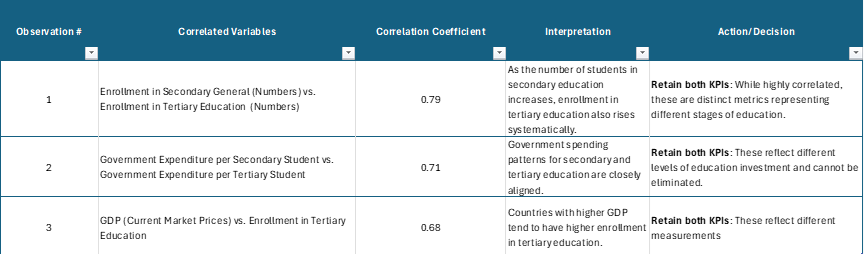



### Graphs: Evolution of indicators over time

Check how all the indicators are evolving over time.

Create two separate graphs for percentages and absolute numbers over time for all the indicators.

Only the years 2010 to 2016 are retained as they have real measurements to appreciate the evolution.

### Enrolment in secondary general, both sexes (number)

#### Enrolment in tertiary education, all programmes, both sexes (number)

#### GDP at market prices (current US$)

#### Government expenditure on secondary education as % of GDP (%)

#### Government expenditure on tertiary education as % of GDP (%)

#### Government expenditure per secondary student (US$)

#### Government expenditure per tertiary student (US$)

#### Internet users (per 100 people)

## Processing 4.1: Weighted Indicator

*   **Time range**: Use indicator values from **2010 to 2024** (after missing value imputation).
*   **Assign incremental weights**:
    *   Apply **year-based weights**, increasing incrementally from 2010 to 2024.
    *   Normalize weights so their **sum equals 1** (2024 receives the highest weight, 2010 the lowest).
*   **Calculate weighted sum**:
    *   Compute a **weighted sum for each indicator**, emphasizing recent years (e.g., 2024 > 2010).
*   **Final output**:
    *   Retain only the **final weighted sum column** for each indicator.
    *   Remove all intermediate year columns.

## Processing 5: Pivot Table Construction and Cost Calculations

*   **Construct pivot table**:
    *   Aggregate indicator values using the **mean** function.
    *   Final pivot table includes:
        *   `Country Code`
        *   `Country Name`
        *   All **selected indicators** as columns.
    *   Result: **8 final indicators** retained for analysis.
*   **Calculate education spending**:
    *   **Method 1**:
        *   Use indicators for **enrollment in tertiary and secondary education (as % of GDP)**.
        *   Multiply by the country’s **GDP** to derive the **absolute monetary amount** spent on secondary and tertiary education.
    *   **Method 2**:
        *   Use indicators for:
            *   Number of students enrolled in **secondary and tertiary education**.
            *   Amount spent **per student** in secondary and tertiary education.
        *   Multiply and sum to derive the **total monetary amount** spent.
    *   **Final value**: Compute the **average** of the two methods to determine the total education spending.
*   **Include additional indicator**:
    *   Use **number of internet users per 100 people** as an additional metric for the final score.

Normalization and Scoring

*   **Normalize indicators**:
    *   Scale the **number of internet users per 100 people** to a **0–1 range** (base 100).
    *   Scale the **total cost on secondary and tertiary education** to a normalized range (0-1) by dividing by the maximum "total cost".
*   **Assign equal weights**:
    *   Apply **weights** to both:
        *   Normalized **total expenditure on education** has 0.85.
        *   Normalized **number of internet users** has 0.15.
    *   **Rationale**: The number of internet users is **critical** for assessing a country's potential.
*   **Calculate final score**:
    *   Sum the weighted normalized indicators.
    *   Final score range: **0 to 1** (weighted).
*   **Sort by score**:
    *   Rank countries based on the final score.
    *   **Preliminary observation**: The **United States** appears to be the most relevant country based on this scoring.

## Processing 6: Display the 20 best countries

In [ ]:
!pip install pycountry

In [ ]:
# importing of all libraries. mounting the google drive
# to retreive files and changing the working directory


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import missingno as msno
import pycountry
import plotly.express as px
import geopandas as gpd
import os


pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')



# Replace 'MyDataFolder' with the actual path to your data folder in Google Drive
drive_data_path = '/content/drive/MyDrive/EDUCATION/data'

# Check if the directory exists before changing the directory
if os.path.exists(drive_data_path):
    os.chdir(drive_data_path)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Error: The directory '{drive_data_path}' was not found.")
    print("Please check the path and make sure your Google Drive is mounted.")

In [ ]:
indicator_data = pd.read_csv('EdStatsSeries.csv')
indicator_data.head()

In [ ]:
indicator_data.shape

In [ ]:
print(indicator_data.duplicated().sum())

In [ ]:
indicator_data.drop_duplicates().reset_index()

In [ ]:
indicator_data.dtypes

In [ ]:
missing_data = indicator_data.isna().mean().sort_values(ascending=False)
print(missing_data)

In [ ]:
indicator_data.info()

In [ ]:
indicator_data.describe()

In [ ]:
# deleting columns with missing values and unnecessary columns through judgement

columns_tokeep = ['Series Code','Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

In [ ]:
# Read the Excel file
indicator_list = pd.read_excel("Indicators.xlsx")

# Make sure to extract the list of Series Codes
codes_to_keep = indicator_list["Series Code"].unique().tolist()

# Filter indicator_data based on the codes
indicator_data = indicator_data[indicator_data["Series Code"].isin(codes_to_keep)]

print(indicator_data)

In [ ]:
country_indicator= pd.read_csv('EdStatsFootNote.csv')
country_indicator.head()

In [ ]:
country_indicator.shape

In [ ]:
missing_values = country_indicator.isna().mean().sort_values(ascending=False)
print(missing_values)

In [ ]:
country_indicator.info()

In [ ]:
country_indicator.describe()

In [ ]:
indicator_values = pd.read_csv('EdStatsData.csv')
indicator_values.head()

In [ ]:
indicator_values.shape

In [ ]:
indicator_values.describe()

In [ ]:
indicator_values.info()

In [ ]:
missing_values=indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

In [ ]:
# Get all valid alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]

# Filter for invalid countries
invalid_countries = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]

# Select both 'Country Code' and 'Country Name' columns, and drop duplicates
unique_invalid_countries = invalid_countries[['Country Code', 'Country Name']].drop_duplicates()

# Print the result of invalid countries
print(unique_invalid_countries)

In [ ]:
# filtering on valid countries only. hence, eliminating other geographic levels like regions.
indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.reset_index()
indicator_values.shape

In [ ]:
# Drop columns for years 1970 to 2007 and 2025 to 2100
years_to_drop = [str(year) for year in range(1970, 2008)] + [str(year) for year in range(2025, 2101)]
indicator_values = indicator_values.drop(columns=years_to_drop, errors='ignore')

# Drop columns that start with "Unnamed"
unnamed_cols = [col for col in indicator_values.columns if col.startswith('Unnamed')]
indicator_values = indicator_values.drop(columns=unnamed_cols, errors='ignore')

# Add columns for years 2017 to 2025 with NaN values
years_to_add = [str(year) for year in range(2017, 2025)]
for year in years_to_add:
    if year not in indicator_values.columns:
        indicator_values[year] = np.nan


# Display the first few rows and columns to verify the changes
display(indicator_values.columns.tolist())

In [ ]:
#Merge the dataframes to acheive a consilidated table



consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Series Code', # Adjust this to match the actual column name in indicator_data
    how="inner"
)

consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

print(consolidated_table.shape)


consolidated_table = consolidated_table[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']]
consolidated_table.head()

In [ ]:
columns_to_check = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')

# Fixed line: removed the 'name' parameter which is not valid for DataFrame.reset_index()
fill_rate_per_group.reset_index().to_csv('fill_rate_per_group.csv', index=False)


# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)

In [ ]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

# Filter the DataFrame
consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
consolidated_table.shape

In [ ]:
consolidated_table.head()

In [ ]:
# make the table to perform correlation analysis

correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name", "Indicator Code", "Indicator Name"],
    value_vars=[ '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
# Drop rows with any NaN values
correlation_data.dropna(how='any', inplace=True);

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()



correlation_data.head()

In [ ]:
# prepare a correlation matrix

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()

In [ ]:
# Get the column names from the correlation matrix
cols = corr_matrix.columns

# Create a mask for the upper triangle of the correlation matrix (excluding the diagonal)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Apply the mask to the correlation matrix and stack the values
stacked_corr = corr_matrix.where(mask).stack()

# Rename the index levels before resetting the index
stacked_corr.index.set_names(['Indicator_1', 'Indicator_2'], inplace=True)

# Convert the stacked series to a DataFrame
corr_flat_table_simple = stacked_corr.reset_index()

# Rename the columns
corr_flat_table_simple.columns = ['Indicator_1', 'Indicator_2', 'Correlation']

# Sort by the absolute correlation value in descending order
corr_flat_table_simple['Absolute Correlation'] = corr_flat_table_simple['Correlation'].abs()
corr_flat_table_simple = corr_flat_table_simple.sort_values(by='Absolute Correlation', ascending=False).drop(columns='Absolute Correlation')

# Export the simplified flattened correlation table to a CSV file
corr_flat_table_simple.to_csv('flattened_correlation_table_simple.csv', index=False)

print("Simplified flattened correlation table created and saved as 'flattened_correlation_table_simple.csv'")

# Display the simplified flattened correlation table
display(corr_flat_table_simple.head())

In [ ]:
# Melt the consolidated table to long format
# Assuming consolidated_table still contains year columns 2010-2024 before the final pivot
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Explicitly melt year columns
)

# Convert Year to numeric
melted_consolidated_table['Year'] = pd.to_numeric(melted_consolidated_table['Year'])

# Filter for years 2010 to 2015
melted_consolidated_table_filtered = melted_consolidated_table[
    (melted_consolidated_table['Year'] >= 2010) & (melted_consolidated_table['Year'] <= 2015)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Calculate the average indicator value per year across countries where data is available
average_indicator_evolution = melted_consolidated_table_filtered.groupby(['Indicator Name', 'Year'])['Value'].mean().reset_index()

# Get unique indicator names
unique_indicators = average_indicator_evolution['Indicator Name'].unique()

In [ ]:
indicator = 'Enrolment in secondary general, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Enrolment in tertiary education, all programmes, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'GDP at market prices (current US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Government expenditure on secondary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Government expenditure on tertiary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Government expenditure per secondary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Government expenditure per tertiary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
indicator = 'Internet users (per 100 people)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#fill missing values for indicators

# Identify the year columns
year_cols = [str(y) for y in range(2010, 2025)]

# Create a copy of the DataFrame to avoid SettingWithCopyWarning
consolidated_table_imputed = consolidated_table.copy()

# Fill missing values per Country + Indicator
for (country_code, country_name, indicator_code, indicator_name), group in consolidated_table_imputed.groupby([
    "Country Code", "Country Name", "Indicator Code", "Indicator Name"
]):
    # Get the indices for this group
    idx = group.index

    # Interpolate the values for this group
    interpolated_values = (
        group[year_cols]
        .interpolate(axis=1, limit_direction='both')  # interpolate gaps
        .ffill(axis=1)                               # forward fill edge NaNs
        .bfill(axis=1)                              # backward fill edge NaNs
    )

    # Update the consolidated_table_imputed with interpolated values using .loc
    consolidated_table_imputed.loc[idx, year_cols] = interpolated_values

# Assign the processed DataFrame back to consolidated_table
consolidated_table = consolidated_table_imputed.copy()

# Drop rows where all indicator values are missing across the year columns
consolidated_table.dropna(subset=year_cols, how='all', inplace=True)


# The code below should be outside the for loop and properly indented
# 1️⃣ Select only numeric columns
# This line seems out of place here based on the previous steps and variable names.
# Assuming it's not needed for the imputation fix, I will comment it out or remove it.
# If it's intended for a later step, it should be in a separate cell.
# numeric_data = indicator_values.select_dtypes(include=['float', 'int'])


msno.matrix(consolidated_table)

In [ ]:
# Define years and linear weights
years = list(range(2010, 2025))
weights = np.arange(1, len(years) + 1)  # [1, 2, 3, ..., 20]
coefficients = weights / weights.sum()  # Normalize to sum=1

print("Before applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

# Multiply each year column by its coefficient
for year, coef in zip(years, coefficients):
    consolidated_table[str(year)] = consolidated_table[str(year)] * coef

# Calculate the weighted mean for each row
year_columns = [str(year) for year in years]
consolidated_table['Indicator Weighted Sum'] = consolidated_table[year_columns].sum(axis=1)

# Print after
print("\nAfter applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

In [ ]:
consolidated_table = consolidated_table[['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 'Indicator Weighted Sum']].copy() # Create a copy here to avoid the warning

consolidated_table ["ind concat"] = consolidated_table ['Indicator Code'] +"/" + consolidated_table['Indicator Name']
consolidated_table.head()

In [ ]:
consolidated_table = consolidated_table.pivot_table(
    index=['Country Code', 'Country Name'],
    columns='ind concat',
    values='Indicator Weighted Sum',
    aggfunc='mean'
).reset_index()

consolidated_table.head()

In [ ]:
display(consolidated_table.columns.tolist())

In [ ]:
# Harmonsing Indicators 1

# Use the exact column names from the pivot table output
consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)'] = consolidated_table['SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$)'] + consolidated_table['SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)'] * consolidated_table['UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$)']

In [ ]:
# Harmonsing Indicators 2

consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] = (consolidated_table['UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%)'] + consolidated_table['UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%)']) * consolidated_table['NY.GDP.MKTP.CD/GDP at market prices (current US$)']

consolidated_table = consolidated_table.rename(
    columns={'IT.NET.USER.P2/Internet users (per 100 people)': 'Internets Users'}
)

# Select the relevant columns after calculations
consolidated_table = consolidated_table[['Country Code',
 'Country Name',
 'Internets Users', 'Total cost on Secondary and Tertairy (Source: Percentage)','Total cost on Secondary and Tertairy (Source: Numbers)']]


 # Calculate the average of the two columns
consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] = (
    consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] +
    consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']
) / 2

# Calculate the absolute delta (percentage difference)
consolidated_table['delta (Numbers and %)'] = abs(
    (consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] -
     consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']) /
    consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)']
)


 # score to calculate a single measure

consolidated_table['Score'] = 0.15 * consolidated_table['Internets Users'] / 100 + 0.75 * (consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] / consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'].max())

consolidated_table= consolidated_table[['Country Code',
 'Country Name',
 'Total Cost on Secondary and Tertiary (Numbers and %)',
 'delta (Numbers and %)',
'Score']].sort_values(
    by='Score',
    ascending=False
)

# Display the top 20 rows
display(consolidated_table.head(20))

In [ ]:
# Select the top 20 countries by score
top_countries = consolidated_table.head(20).copy()

# Define a color palette for the top 5 countries and a single color for the rest
colors = sns.color_palette('viridis', 5) + ['grey'] * (len(top_countries) - 5)

# Create a bar chart
plt.figure(figsize=(12, 8))
# Assign colors directly to the palette argument, mapping them to the 'Country Name' order
sns.barplot(x='Score', y='Country Name', data=top_countries, palette=colors, hue='Country Name', legend=False)

plt.title('Top 20 Countries by Score')
plt.xlabel('Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()